In [1]:
import os
os.chdir('/workspace/bee28059-7adf-4f22-8559-b6d2a9374313')
print(os.listdir('.'))


['.prompts', 'weil_J_sweep_ldh_results.json', '.kernel_llm_logs_1.txt', '.config', 'memory', 'ldh_zeros_partial_dps50.npy', 'weil_J_sweep_single_shift_results.json', 'ldh_def.py']


In [2]:
import json
with open('weil_J_sweep_ldh_results.json') as f:
 ldh_res = json.load(f)
with open('weil_J_sweep_single_shift_results.json') as f:
 zeta_res = json.load(f)
print("LDH keys:", list(ldh_res.keys()))
print()
print("LDH params:", ldh_res.get('parameters', ldh_res.get('params')))


LDH keys: ['parameters', 'J_values', 'lambda_min_lchi', 'lambda_max_lchi', 'lambda_min_ldh_offcrit', 'lambda_max_ldh_offcrit', 'lambda_min_ldh_crit_only', 'lambda_max_ldh_crit_only', 'analysis']

LDH params: {'T0': '85.7', 'sigma': '2.0', 'half_window': '40.0', 'prime_bound': 1000, 'dps': 80, 'M_zeros_formula': 'for zero at 1/2+beta+i*gamma: contribute Re[v v^T] with v = h(±gamma - i*beta) (functional-equation pair, no conjugation)', 'M_arith_formula': 'sum_{p,k: p^k<=prime_bound} Re[Lambda(p^k)]/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]', 'Lambda_chi': 'Lambda_chi(p^k) = chi(p)^k * log(p) (complex; we use Re part)', 'Lambda_DH': 'Lambda_DH(p^k) from recurrence on Dirichlet coeffs c_n = A*chi(n) + B*chibar(n) of L_DH (real)', 'L_DH_off_critical_zero': {'gamma': '85.699348485377592171929267708941729037987829423407575924765024463854574584004397', 'beta_pair': ['0.30851718245663738555335196060684412785067026830501462250439870858155011800810091', '-0.308517182456637

In [3]:
print("J_values:", ldh_res['J_values'])
print("LDH off-crit lambda_min:", ldh_res['lambda_min_ldh_offcrit'])
print("LDH crit only lambda_min:", ldh_res['lambda_min_ldh_crit_only'])
print("Lchi lambda_min:", ldh_res['lambda_min_lchi'])
print()
print("zeta_res keys:", list(zeta_res.keys()))
print("zeta params:", zeta_res.get('parameters'))


J_values: [4, 8, 12, 16, 20]
LDH off-crit lambda_min: [0.17293066452683875, -0.015689552756595115, -0.01898305822234395, -0.028435580315451656, -0.03495023860480681]
LDH crit only lambda_min: [0.06545907206516281, 0.0007124844005979207, 2.2840516370960682e-07, 7.089777522122622e-13, 2.4007529865813553e-21]
Lchi lambda_min: [0.22896404432300493, 0.0299431333928687, 0.003437512676670098, 1.1950772123599212e-06, 3.33626741447568e-13]

zeta_res keys: ['description', 'parameters', 'J_values', 'lambda_min_zeta_single_shift', 'lambda_max_zeta_single_shift', 'lambda_min_zeta_crit_only', 'lambda_max_zeta_crit_only', 'comparison', 'log_log_local_slopes', 'fits_J8_to_J20', 'conclusion']
zeta params: {'T0': '46.1347251417347', 'sigma': '1.0', 'half_window': '20.0', 'prime_bound': 1000, 'dps': 80, 'delta': '0.05', 'zeros_in_window': 12, 'shifted_zero_index_in_window': 5, 'shifted_zero_gamma': '48.005150881167159727942472749427516041686844001144', 'shifted_zero_label': 'gamma_9 (closest to T0=46.13 

In [4]:
print("zeta single shift lambda_min:", zeta_res['lambda_min_zeta_single_shift'])
print("zeta crit only lambda_min:", zeta_res['lambda_min_zeta_crit_only'])
print()
print("zeta fits:", zeta_res.get('fits_J8_to_J20'))
print()
print("ldh analysis:", ldh_res.get('analysis'))


zeta single shift lambda_min: [-0.00017588931453140318, -0.005469174291454321, -0.3840812775774776, -56.90127697594482, -1738.0261319017789]
zeta crit only lambda_min: [7.782845486781603e-11, 1.1176654040531937e-70, -3.0431170845949793e-82, -1.9689884538063704e-79, -1.0782466669088964e-75]

zeta fits: {'power_law_alpha': {'multi': 28.242704189282815, 'single': 13.975311690480662, 'ldh': 0.9038640584609486}, 'exp_rate': {'multi': 2.2166958185993244, 'single': 1.0751404443548642, 'ldh': 0.07017212458010649}}

ldh analysis: {'comparison_with_r24_zeta_delta': {'r24_zeta_delta_power_law_alpha': 17.9, 'r24_zeta_delta_exp_rate_a': 1.926, 'r24_zeta_delta_super_exp_rate': 0.569, 'this_ldh_offcrit_power_law_alpha_J8_20': 0.9038640584609449, 'this_ldh_offcrit_exp_rate_a_J8_20': 0.07017212458010666, 'this_ldh_offcrit_super_exp_rate_J8_20': 0.019430501999113725, 'conclusion': 'L_DH off-critical lambda_min grows much more slowly than zeta_delta; growth is roughly linear in J (alpha~0.9), not super-p

In [5]:
import numpy as np
# Load LDH zeros
ldh_zeros_str = np.load('ldh_zeros_partial_dps50.npy', allow_pickle=True)
print(type(ldh_zeros_str), ldh_zeros_str.shape, ldh_zeros_str.dtype)
print("first:", ldh_zeros_str[0])
print("last:", ldh_zeros_str[-1])


<class 'numpy.ndarray'> (2772,) object
first: 5.0941598445710949256987955170797974750670744531091
last: 2827.6969810118514746665829496729953578196456980475


In [6]:
import mpmath
mpmath.mp.dps = 80

# Validate the basis hypothesis by reproducing one number from the existing JSON for "ldh_crit_only" at small J
# Start by implementing and testing on the simpler L_DH critical-only case which uses the SAME basis but 
# uses Λ_DH on arithmetic side. Actually we don't need this verification — let's instead reproduce the 
# zeta_crit_only result with a known-correct h(u) form because zeta deformation result uses the same basis.

# Reproduction check: zeta_res has lambda_min_zeta_crit_only at T0=46.1347251417347, sigma=1.0, dps=80
# Using zeros of zeta... but we don't have zeta zeros file here. Let's load them.
import os
print([f for f in os.listdir('.') if 'zeta' in f.lower()])
print([f for f in os.listdir('.') if 'lchi' in f.lower() or 'ldelta' in f.lower()])


[]
[]


In [7]:
# We don't have the zeta zeros file in this workspace. Let's check if zeros files exist elsewhere
import subprocess
out = subprocess.run(['find', '/workspace', '-name', '*.npy', '-size', '+1k'], capture_output=True, text=True)
print(out.stdout[:3000])


/workspace/bee28059-7adf-4f22-8559-b6d2a9374313/ldh_zeros_partial_dps50.npy



In [8]:
# Only LDH zeros are here. That's what we need. We are computing the L_DH-with-mismatched-arithmetic case.
# We need to validate our basis implementation. Best validation: reproduce the "lambda_min_ldh_crit_only" 
# numbers from the JSON using the same L_DH zeros (critical line only), with Lambda_DH arithmetic.
# OR reproduce "lambda_min_ldh_offcrit" which adds the off-critical pair.

# Plan:
# 1. Implement Weil form with Gaussian-monomial basis (J basis funcs):
# h_j(u) = u^j * exp(-(u - T0)^2/(2 sigma^2)) for j=0,...,J-1
# 2. Compute M_zeros from zeros in [T0 - half_window, T0 + half_window] ∪ negatives (functional eq):
# For each zero at 1/2 + beta + i*gamma (beta=0 for critical zeros),
# contribution: Re[v_+ v_+^T] + Re[v_- v_-^T], where v_± = h(±gamma - i*beta).
# Actually the JSON says "v = h(±gamma - i*beta) (functional-equation pair)" — meaning we use both signs.
# 3. Compute M_arith using Lambda_DH (for original LDH check) or log(p) (for our experiment Q').
# 4. Verify: compute lambda_min for J=4..20 for the LDH off-critical case and compare to JSON values.
# 5. Then compute Q' using mismatched zeta-style arithmetic and compute lambda_min vs J.

# First we need Lambda_DH(p^k) — recurrence on Dirichlet coefficients
# c_n = A*chi(n) + B*chi_bar(n) (real-valued because A=conj(B) and chi_bar = conj(chi))
# L_DH(s) = sum c_n / n^s
# Then log L_DH(s) = sum_{n>=2} (Lambda_DH(n)/log n) / n^s = sum_{n>=2} Lambda_DH_tilde(n) / n^s
# Standard: Lambda(n) is non-zero only at prime powers when there's an Euler product.
# But L_DH has no Euler product, so Lambda_DH(n) is generally non-zero at ALL n>=2.
# However the JSON formula says: M_arith for L_DH = sum_{p,k: p^k<=prime_bound} Re[Lambda_DH(p^k)]/sqrt(p^k) * [...]
# So only prime powers are kept (even though Lambda_DH(n) is nonzero at composites too).

# Actually re-reading: "Lambda_DH(p^k) from recurrence on Dirichlet coeffs". This means evaluating 
# Lambda_DH at prime powers only. The recurrence is the standard one:
# c_n * log(n) = sum_{d|n} Lambda_DH(d) * c_{n/d}
# which gives Lambda_DH at ALL integers, but the M_arith sum only includes prime power terms (p^k <= 1000).

# Let's import ldh_def
from ldh_def import L_DH, CHI_LIST, CHI_BAR_LIST, _A, _B
import mpmath
mpmath.mp.dps = 80

# Compute c_n = A*chi(n) + B*chi_bar(n) for n=1..N
# chi has period 5: chi(n mod 5)
def chi_val(n, lst):
 return lst[n % 5]

A = _A
B = _B
print("A =", A)
print("B =", B)
print("c(1) =", A*chi_val(1, CHI_LIST) + B*chi_val(1, CHI_BAR_LIST)) # should be 1 (real)
print("c(2) =", A*chi_val(2, CHI_LIST) + B*chi_val(2, CHI_BAR_LIST))
print("c(3) =", A*chi_val(3, CHI_LIST) + B*chi_val(3, CHI_BAR_LIST))


A = (0.5 - 0.14203952192020614801414591619656308454554404422286708195196357375413827508339737j)
B = (0.5 + 0.14203952192020614801414591619656308454554404422286708195196357375413827508339737j)
c(1) = (1.0 + 0.0j)
c(2) = (0.28407904384041229602829183239312616909108808844573416390392714750827655016679474 + 0.0j)
c(3) = (-0.28407904384041229602829183239312616909108808844573416390392714750827655016679474 + 0.0j)


In [9]:
# Good - c_n is real. Now compute Lambda_DH(n) via recurrence:
# c_n * log(n) = sum_{d|n, d>=2} Lambda_DH(d) * c_{n/d} for n>=2
# Equivalent rearrangement:
# Lambda_DH(n) = log(n) (when n is prime) — but for composites it's nontrivial.
# Better: -L'/L(s) = sum_{n>=2} Lambda_DH(n) / n^s
# Use the standard identity: sum_{d|n} Lambda_DH(d) * c_{n/d} = c_n * log(n)
# So Lambda_DH(n) = c_n * log(n) - sum_{d|n, 1<d<n} Lambda_DH(d) * c_{n/d} [using c_1=1]

def compute_Lambda_DH_table(Nmax):
 cn = [mpmath.mpf(0)] * (Nmax+1)
 cn[0] = mpmath.mpc(0) # unused
 for n in range(1, Nmax+1):
 v = A*chi_val(n, CHI_LIST) + B*chi_val(n, CHI_BAR_LIST)
 cn[n] = mpmath.re(v) # it's real
 Lam = [mpmath.mpf(0)] * (Nmax+1)
 for n in range(2, Nmax+1):
 # Lambda(n) = c_n*log(n) - sum_{d|n, 1<d<n} Lambda(d)*c_{n/d}
 s = cn[n] * mpmath.log(n)
 # subtract contributions from proper divisors d (1<d<n)
 for d in range(2, n):
 if n % d == 0:
 s -= Lam[d] * cn[n // d]
 Lam[n] = s
 return Lam, cn

# Test small values: Lambda_DH at primes should be log(p)? 
# For an Euler-product L-function we'd have Lambda(p) = c_p * log(p) but for L_DH (no Euler product) this fails generally.
# Actually wait: Lambda is defined by -L'/L(s) = sum Lambda(n) n^{-s}. For Euler product L: Lambda(n) supported on prime powers.
# For non-Euler L_DH: Lambda(n) generally supported everywhere.
# At n=p prime: c_p*log(p) - 0 = Lambda(p)*c_1 = Lambda(p). So Lambda(p) = c_p * log(p). NOT log(p).
Lam_test, cn_test = compute_Lambda_DH_table(15)
for n in [2,3,4,5,6,7,8,9,10]:
 print(f"n={n}: c_n={float(cn_test[n]):.6f}, Lambda_DH(n)={float(Lam_test[n]):.6f}")


n=2: c_n=0.284079, Lambda_DH(n)=0.196909
n=3: c_n=-0.284079, Lambda_DH(n)=-0.312093
n=4: c_n=-1.000000, Lambda_DH(n)=-1.442232
n=5: c_n=0.000000, Lambda_DH(n)=0.000000
n=6: c_n=1.000000, Lambda_DH(n)=1.936356
n=7: c_n=0.284079, Lambda_DH(n)=0.552792
n=8: c_n=-0.284079, Lambda_DH(n)=0.015891
n=9: c_n=-1.000000, Lambda_DH(n)=-2.285884
n=10: c_n=0.000000, Lambda_DH(n)=0.000000


In [10]:
# Good. Now build M_arith using only prime powers (per the JSON's recorded formula).
# Verify with original LDH crit-only / off-crit cases.

# Implementation of Weil form:
# Basis: h_j(u) = u^j * exp(-(u - T0)^2 / (2 sigma^2)) for j=0..J-1
# For zero at 1/2 + beta + i*gamma:
# v_+ = h(+gamma - i*beta) (j-th entry = (gamma - i*beta)^j * exp(-(gamma - i*beta - T0)^2/(2 sigma^2)))
# v_- = h(-gamma - i*beta)
# contribution: Re[v_+ v_+^T] + Re[v_- v_-^T]
#
# For arithmetic side at p^k:
# u = k*log(p)
# v_+ = h(u), v_- = h(-u) (these are real since u real)
# contribution: Re[Lambda(p^k)]/sqrt(p^k) * (v_+ v_+^T + v_- v_-^T)

import mpmath
mpmath.mp.dps = 80

def make_h_vec(u, T0, sigma, J):
 """Return J-dim mpmath complex vector h(u). u may be complex."""
 u = mpmath.mpc(u) if not isinstance(u, mpmath.mpc) else u
 T0 = mpmath.mpf(T0)
 sigma = mpmath.mpf(sigma)
 env = mpmath.exp(-(u - T0)**2 / (2*sigma**2))
 return [u**j * env for j in range(J)]

def outer_re(v):
 """Return Re[v v^T] as J x J list of lists of mpf."""
 J = len(v)
 M = [[mpmath.mpf(0)]*J for _ in range(J)]
 for i in range(J):
 for j in range(J):
 M[i][j] = mpmath.re(v[i]*v[j])
 return M

def add_to(M, contrib, scale=mpmath.mpf(1)):
 J = len(M)
 for i in range(J):
 for j in range(J):
 M[i][j] += scale * contrib[i][j]

def zeros_matrix(zeros, T0, sigma, J):
 """zeros: list of (beta, gamma) tuples (mpf)."""
 M = [[mpmath.mpf(0)]*J for _ in range(J)]
 for (beta, gamma) in zeros:
 u_plus = mpmath.mpc(gamma, -beta) # +gamma - i*beta
 u_minus = mpmath.mpc(-gamma, -beta) # -gamma - i*beta
 v_p = make_h_vec(u_plus, T0, sigma, J)
 v_m = make_h_vec(u_minus, T0, sigma, J)
 add_to(M, outer_re(v_p))
 add_to(M, outer_re(v_m))
 return M

def arith_matrix(Lam_table, prime_bound, T0, sigma, J):
 """M_arith = sum_{p^k <= prime_bound} Re[Lambda(p^k)]/sqrt(p^k) * [h(k log p) h^T + h(-k log p) h^T]"""
 # Find primes up to prime_bound
 from sympy import primerange
 M = [[mpmath.mpf(0)]*J for _ in range(J)]
 for p in primerange(2, prime_bound+1):
 k = 1
 pk = p
 while pk <= prime_bound:
 u = mpmath.mpf(k) * mpmath.log(p)
 v_p = make_h_vec(u, T0, sigma, J)
 v_m = make_h_vec(-u, T0, sigma, J)
 scale = mpmath.re(Lam_table[pk]) / mpmath.sqrt(pk)
 add_to(M, outer_re(v_p), scale)
 add_to(M, outer_re(v_m), scale)
 k += 1
 pk = p**k
 return M

print("Setup OK")


Setup OK


In [11]:
# For the zeta-style mismatched arithmetic, Lambda(p^k) = log(p) for prime powers, 0 elsewhere
# We can build a "fake Lambda table" with these values for the M'_arith.

# First, let me verify the implementation by reproducing the LDH off-critical result for J=4.
# T0=85.7, sigma=2.0, half_window=40.0
# Zeros in window: gamma in [85.7-40, 85.7+40] = [45.7, 125.7]
# Plus the off-critical pair at gamma≈85.6993, beta=±0.30852
# JSON said 49 critical zeros in window.

# Load the LDH zeros
import numpy as np
ldh_zeros_arr = np.load('ldh_zeros_partial_dps50.npy', allow_pickle=True)
# Convert to mpf
ldh_zeros = [mpmath.mpf(s) for s in ldh_zeros_arr]
print("Total LDH zeros:", len(ldh_zeros))

T0 = mpmath.mpf("85.7")
sigma = mpmath.mpf("2.0")
half_window = mpmath.mpf("40.0")

# Critical-line zeros in [T0-hw, T0+hw]
crit_in_window = [(mpmath.mpf(0), g) for g in ldh_zeros if T0-half_window <= g <= T0+half_window]
print("Number critical zeros in window:", len(crit_in_window)) # should be 49

# Off-critical pair
gamma_off = mpmath.mpf("85.699348485377592171929267708941729037987829423407575924765024463854574584004397")
beta_off = mpmath.mpf("0.30851718245663738555335196060684412785067026830501462250439870858155011800810091")
off_pair = [(beta_off, gamma_off), (-beta_off, gamma_off)]


Total LDH zeros: 2772
Number critical zeros in window: 49


In [12]:
# Good, matches the JSON (49 critical zeros). Now build Lambda_DH table up to 1000.
# This requires divisor enumeration up to 1000. Naive O(n^2) — let's use a faster approach.

import time
def compute_Lambda_DH_table_fast(Nmax):
 cn = [mpmath.mpf(0)] * (Nmax+1)
 for n in range(1, Nmax+1):
 v = A*chi_val(n, CHI_LIST) + B*chi_val(n, CHI_BAR_LIST)
 cn[n] = mpmath.re(v)
 Lam = [mpmath.mpf(0)] * (Nmax+1)
 # Lambda(n) = c_n*log(n) - sum_{d|n, 1<d<n} Lambda(d) * c_{n/d}
 # Build divisors more efficiently
 from sympy import divisors
 for n in range(2, Nmax+1):
 s = cn[n] * mpmath.log(n)
 for d in divisors(n):
 if d > 1 and d < n:
 s -= Lam[d] * cn[n // d]
 Lam[n] = s
 return Lam

t0 = time.time()
Lam_DH = compute_Lambda_DH_table_fast(1000)
print(f"Lambda_DH table built in {time.time()-t0:.2f}s")
print("Lambda_DH(2)=", Lam_DH[2])
print("Lambda_DH(4)=", Lam_DH[4])
print("Lambda_DH(8)=", Lam_DH[8])
print("Lambda_DH(1000)=", Lam_DH[1000])


Lambda_DH table built in 0.74s
Lambda_DH(2)= 0.19690858829414688113150679575063496747656984257993407868389516965975589921550544
Lambda_DH(4)= -1.4422319646064572661237110591109437776319833265791730560902402098762261176813997
Lambda_DH(8)= 0.015890700913187966298113438243049397726180538278983161835551869931373853178634799
Lambda_DH(1000)= 0.0


In [13]:
# Now compute eigenvalues for J=4 to verify against the JSON value.
# JSON: lambda_min_ldh_offcrit at J=4 = 0.17293066452683875

# Build M_zeros from critical + off-critical pair
zeros_offcrit = crit_in_window + off_pair
prime_bound = 1000

def lambda_min_max(M):
 """Compute eigenvalues of mpmath J x J matrix; return smallest and largest real parts."""
 M_mp = mpmath.matrix(M)
 eigvals = mpmath.eig(M_mp, left=False, right=False)
 re_eigs = [mpmath.re(e) for e in eigvals]
 return min(re_eigs), max(re_eigs)

t0 = time.time()
J = 4
Mz = zeros_matrix(zeros_offcrit, T0, sigma, J)
Ma = arith_matrix(Lam_DH, prime_bound, T0, sigma, J)
Q = [[Mz[i][j] - Ma[i][j] for j in range(J)] for i in range(J)]
lmin, lmax = lambda_min_max(Q)
print(f"J={J}: lambda_min={float(lmin):.6g}, lambda_max={float(lmax):.6g} (time {time.time()-t0:.1f}s)")
print(f"JSON expected lambda_min={ldh_res['lambda_min_ldh_offcrit'][0]:.6g}")


J=4: lambda_min=1.72867e-10, lambda_max=1.07387e+12 (time 0.1s)
JSON expected lambda_min=0.172931


In [14]:
# Mismatch — the JSON value 0.172931 vs my 1.7e-10. Let me think about the basis.
# The issue is likely that the basis functions are way too large since u^j at u≈85 with sigma=2 envelope
# centered at T0=85.7 gives huge entries (85^20 ~ 10^38). The eigenvalues should not depend on overall 
# basis scaling, but the *ratio* between lambda_min and lambda_max is what matters.

# Actually the JSON has lambda_min ~ O(1) and we got 1.7e-10. The relative scale: lambda_max=1e12.
# Our matrix is dominated by very large values. The eigenvalues 0.17/1e12 ≈ 1e-13 — that's the relative.
# Our 1.7e-10/1e12 = 1.7e-22 — different ratio.

# Maybe the basis isn't h_j(u) = u^j * env, but rather h_j(u) = ((u-T0)/sigma)^j * env (shifted/scaled monomials).
# That makes the basis well-conditioned. Let's try.

def make_h_vec_v2(u, T0, sigma, J):
 u = mpmath.mpc(u) if not isinstance(u, mpmath.mpc) else u
 T0 = mpmath.mpf(T0)
 sigma = mpmath.mpf(sigma)
 env = mpmath.exp(-(u - T0)**2 / (2*sigma**2))
 x = (u - T0) / sigma
 return [x**j * env for j in range(J)]

def outer_re_v(v):
 J = len(v)
 M = mpmath.matrix(J, J)
 for i in range(J):
 for j in range(J):
 M[i,j] = mpmath.re(v[i]*v[j])
 return M

def zeros_matrix_v2(zeros, T0, sigma, J, h_func):
 M = mpmath.matrix(J, J)
 for (beta, gamma) in zeros:
 u_plus = mpmath.mpc(gamma, -beta)
 u_minus = mpmath.mpc(-gamma, -beta)
 v_p = h_func(u_plus, T0, sigma, J)
 v_m = h_func(u_minus, T0, sigma, J)
 M += outer_re_v(v_p)
 M += outer_re_v(v_m)
 return M

def arith_matrix_v2(Lam_table, prime_bound, T0, sigma, J, h_func):
 from sympy import primerange
 M = mpmath.matrix(J, J)
 for p in primerange(2, prime_bound+1):
 k = 1
 pk = p
 while pk <= prime_bound:
 u = mpmath.mpf(k) * mpmath.log(p)
 v_p = h_func(u, T0, sigma, J)
 v_m = h_func(-u, T0, sigma, J)
 scale = mpmath.re(Lam_table[pk]) / mpmath.sqrt(pk)
 Mp = outer_re_v(v_p)
 Mm = outer_re_v(v_m)
 for i in range(J):
 for j in range(J):
 M[i,j] += scale * (Mp[i,j] + Mm[i,j])
 k += 1
 pk = p**k
 return M

t0 = time.time()
J = 4
Mz2 = zeros_matrix_v2(zeros_offcrit, T0, sigma, J, make_h_vec_v2)
Ma2 = arith_matrix_v2(Lam_DH, prime_bound, T0, sigma, J, make_h_vec_v2)
Q2 = Mz2 - Ma2
eigvals = mpmath.eig(Q2, left=False, right=False)
re_eigs = [float(mpmath.re(e)) for e in eigvals]
print(f"J={J} (v2 shifted basis): lambda_min={min(re_eigs):.6g}, lambda_max={max(re_eigs):.6g}")
print(f"All eigs:", sorted(re_eigs))
print(f"JSON expected lambda_min={ldh_res['lambda_min_ldh_offcrit'][0]:.6g}")
print(f"Time: {time.time()-t0:.1f}s")


J=4 (v2 shifted basis): lambda_min=0.172931, lambda_max=5.25653
All eigs: [0.17293066452683875, 1.2082538512417746, 3.187888205492916, 5.256530491496579]
JSON expected lambda_min=0.172931
Time: 0.1s


In [15]:
# Excellent! Perfect match: 0.172931 vs JSON 0.17293066. The basis is h_j(u) = ((u-T0)/sigma)^j * exp(-(u-T0)^2/(2 sigma^2)).
# Let me also verify J=8 to be sure.

import time
J = 8
t0 = time.time()
Mz = zeros_matrix_v2(zeros_offcrit, T0, sigma, J, make_h_vec_v2)
Ma = arith_matrix_v2(Lam_DH, prime_bound, T0, sigma, J, make_h_vec_v2)
Q = Mz - Ma
eigvals = mpmath.eig(Q, left=False, right=False)
re_eigs = sorted([float(mpmath.re(e)) for e in eigvals])
print(f"J={J}: lambda_min={re_eigs[0]:.6g}, JSON expected={ldh_res['lambda_min_ldh_offcrit'][1]:.6g}")
print(f"Time: {time.time()-t0:.1f}s")


J=8: lambda_min=-0.0156896, JSON expected=-0.0156896
Time: 0.3s


In [16]:
# Perfect match. Implementation validated.
# Now: build the ζ-style mismatched arithmetic Lambda table (Lambda_zeta(p^k) = log(p)) up to 1000.

from sympy import primerange

def make_Lam_zeta_table(Nmax):
 Lam = [mpmath.mpf(0)] * (Nmax+1)
 for p in primerange(2, Nmax+1):
 pk = p
 while pk <= Nmax:
 Lam[pk] = mpmath.log(p)
 pk *= p
 return Lam

Lam_zeta = make_Lam_zeta_table(1000)
print("Lam_zeta(2)=", Lam_zeta[2]) # log 2
print("Lam_zeta(4)=", Lam_zeta[4]) # log 2
print("Lam_zeta(8)=", Lam_zeta[8]) # log 2
print("Lam_zeta(9)=", Lam_zeta[9]) # log 3
print("Lam_zeta(6)=", Lam_zeta[6]) # 0 (composite, non prime power)


Lam_zeta(2)= 0.69314718055994530941723212145817656807550013436025525412068000949339362196969472
Lam_zeta(4)= 0.69314718055994530941723212145817656807550013436025525412068000949339362196969472
Lam_zeta(8)= 0.69314718055994530941723212145817656807550013436025525412068000949339362196969472
Lam_zeta(9)= 1.098612288668109691395245236922525704647490557822749451734694333637494293218609
Lam_zeta(6)= 0.0


In [17]:
# Now compute Q' = M_zeros - M'_arith for J=4,8,12,16,20 using LDH zeros (with off-critical pair) but zeta-style arithmetic.

import time

J_values = [4, 8, 12, 16, 20]
lambda_min_mismatched = []
lambda_max_mismatched = []
all_eigs_mismatched = {}

for J in J_values:
 t0 = time.time()
 Mz = zeros_matrix_v2(zeros_offcrit, T0, sigma, J, make_h_vec_v2)
 Ma_prime = arith_matrix_v2(Lam_zeta, prime_bound, T0, sigma, J, make_h_vec_v2)
 Qp = Mz - Ma_prime
 eigvals = mpmath.eig(Qp, left=False, right=False)
 re_eigs = sorted([float(mpmath.re(e)) for e in eigvals])
 lambda_min_mismatched.append(re_eigs[0])
 lambda_max_mismatched.append(re_eigs[-1])
 all_eigs_mismatched[J] = re_eigs
 print(f"J={J}: lambda_min={re_eigs[0]:.6g}, lambda_max={re_eigs[-1]:.6g}, |lambda_min|={abs(re_eigs[0]):.6g} ({time.time()-t0:.1f}s)")


J=4: lambda_min=0.172931, lambda_max=5.25653, |lambda_min|=0.172931 (0.1s)


J=8: lambda_min=-0.0156896, lambda_max=2570.8, |lambda_min|=0.0156896 (0.3s)


J=12: lambda_min=-0.0189831, lambda_max=1.55122e+07, |lambda_min|=0.0189831 (0.6s)


J=16: lambda_min=-0.0284356, lambda_max=4.44271e+11, |lambda_min|=0.0284356 (1.0s)


J=20: lambda_min=-0.0349502, lambda_max=3.90456e+16, |lambda_min|=0.0349502 (1.6s)


In [18]:
# Wait — the mismatched lambda_min values are IDENTICAL to the LDH off-crit values!
# J=4: 0.172931 (same as JSON's lambda_min_ldh_offcrit[0]=0.17293066)
# J=8: -0.0156896 (same as JSON's -0.015689552)
# J=12: -0.0189831 (same as JSON's -0.01898305822)
# J=16: -0.0284356 (same as JSON's -0.028435580)
# J=20: -0.0349502 (same as JSON's -0.034950238)

# Let me confirm this is real and not a bug:
print("My mismatched (Q'):", lambda_min_mismatched)
print("JSON LDH off-crit :", ldh_res['lambda_min_ldh_offcrit'])
# Indeed identical to high precision!

# This is unexpected — but actually, let's check lambda_max:
print()
print("My mismatched lambda_max:", lambda_max_mismatched)
print("JSON LDH off-crit lambda_max:", ldh_res['lambda_max_ldh_offcrit'])


My mismatched (Q'): [0.17293066452683875, -0.015689552756595115, -0.01898305822234395, -0.028435580315451656, -0.03495023860480681]
JSON LDH off-crit : [0.17293066452683875, -0.015689552756595115, -0.01898305822234395, -0.028435580315451656, -0.03495023860480681]

My mismatched lambda_max: [5.256530491496579, 2570.804774826574, 15512242.624877013, 444271382028.8717, 3.904560763953769e+16]
JSON LDH off-crit lambda_max: [5.256530491496579, 2570.804774826574, 15512242.624877013, 444271382028.8717, 3.904560763953769e+16]


In [19]:
# IDENTICAL results! Even the lambda_max. Let me verify carefully — is something off?
# 
# Theory check: The window for h(u) is Gaussian centered at T0=85.7 with width sigma=2.0.
# For arithmetic side terms at u = k*log(p), with p<=1000 and k>=1:
# - k*log(p) for p<=1000, k>=1: max k*log p = log(1000) = 6.91, min positive ≈ log(2)=0.693
# - But also -u: range [-6.91, -0.693]
# These u values are FAR from T0=85.7. The Gaussian envelope exp(-(u-85.7)^2/8) is essentially 0.
# E.g., exp(-(6.91 - 85.7)^2/8) = exp(-776.6) ≈ 1e-337
# So M_arith ≈ 0 to within numerical precision!
# Therefore Q ≈ M_zeros and the arithmetic side effectively does NOT contribute.
# That's why our mismatched and matched results are essentially identical.

# Let me check the magnitude of M_arith:
J = 4
Ma_ldh = arith_matrix_v2(Lam_DH, prime_bound, T0, sigma, J, make_h_vec_v2)
Ma_zeta = arith_matrix_v2(Lam_zeta, prime_bound, T0, sigma, J, make_h_vec_v2)
print("Max abs in M_arith (LDH):", max(abs(Ma_ldh[i,j]) for i in range(J) for j in range(J)))
print("Max abs in M_arith (zeta):", max(abs(Ma_zeta[i,j]) for i in range(J) for j in range(J)))
print("Max abs in M_zeros:", end=" ")
Mz4 = zeros_matrix_v2(zeros_offcrit, T0, sigma, J, make_h_vec_v2)
print(max(abs(Mz4[i,j]) for i in range(J) for j in range(J)))


Max abs in M_arith (LDH): 1.0775702475924360845007689103110285193956024493088290140840114917703328747118333e-665
Max abs in M_arith (zeta): 2.8008667059933770660767084475329818816693127522991495299609660868892160930125109e-665
Max abs in M_zeros: 4.5653045838012229031974003947818869766664661041231424463986532390745321261453185


In [20]:
# Aha! This is the key issue. Both M_arith are ~1e-665 — essentially zero.
# The reason: at T0=85.7 with sigma=2.0, the Gaussian envelope at u=k*log(p) (where u ~ 0-7) gives 
# exp(-(0-85.7)^2/(2*4)) = exp(-918) ≈ 1e-399 (for k log p ~ 0)
# So M_arith contributes nothing — Q = M_zeros - M_arith ≈ M_zeros.
# This means the mismatched arithmetic side hypothesis test gives IDENTICAL results to the matched test.

# But wait — the original r28/r32 analysis already had a weak signal for LDH. The hypothesis is that 
# this weak signal is due to cancellation. But here we see M_arith ≈ 0, so there's no cancellation 
# to break! The weak signal must come from M_zeros itself, not from cancellation.

# So this experiment actually REFUTES the hypothesis: replacing M_arith with mismatched zeta-style 
# gives identical results because M_arith has no measurable effect at T0=85.7.

# Let me compute the power-law exponent alpha for |lambda_min| vs J (for J=8..20, since J=4 is positive).
import numpy as np

J_arr = np.array([8, 12, 16, 20])
lmin_mismatched = np.array([abs(x) for x in lambda_min_mismatched[1:]]) # J=8..20
log_J = np.log(J_arr)
log_lmin = np.log(lmin_mismatched)
# Linear fit: log|lmin| = alpha * log J + const
slope, intercept = np.polyfit(log_J, log_lmin, 1)
print(f"Power-law alpha (mismatched LDH, J=8..20): {slope:.4f}")
print(f"|lmin| values (J=8..20): {lmin_mismatched}")

# Compare to original LDH
lmin_ldh = np.array([abs(x) for x in ldh_res['lambda_min_ldh_offcrit'][1:]])
slope_ldh, _ = np.polyfit(log_J, np.log(lmin_ldh), 1)
print(f"Power-law alpha (original LDH, JSON, J=8..20): {slope_ldh:.4f}")

# And the zeta single shift
lmin_zeta_single = np.array([abs(x) for x in zeta_res['lambda_min_zeta_single_shift'][1:]])
slope_zeta_s, _ = np.polyfit(log_J, np.log(lmin_zeta_single), 1)
print(f"Power-law alpha (zeta single shift, JSON, J=8..20): {slope_zeta_s:.4f}")


Power-law alpha (mismatched LDH, J=8..20): 0.9039
|lmin| values (J=8..20): [0.01568955 0.01898306 0.02843558 0.03495024]
Power-law alpha (original LDH, JSON, J=8..20): 0.9039
Power-law alpha (zeta single shift, JSON, J=8..20): 13.9753


In [21]:
# The result is unambiguous:
# - Mismatched LDH alpha = 0.9039 (identical to original LDH)
# - Original LDH alpha = 0.9039
# - Zeta single shift alpha = 13.9753
#
# Hypothesis REFUTED. The weak signal is NOT due to cancellation between M_zeros and M_arith.
# The arithmetic side is essentially zero (~1e-665) at this T0/sigma because the Gaussian envelope 
# centered at T0=85.7 with sigma=2.0 has no support at the prime-power log values u ∈ [0.7, 7].
# So M_arith doesn't matter, and replacing it doesn't change anything.

# The weak signal comes from M_zeros = sum of Re[v v^T] terms. The off-critical pair contributes 
# beta-related terms that are small for the given J range — but that's structural to L_DH's specific 
# off-critical zero, not due to cancellation with M_arith.

# Save results
import json

results = {
 "description": "Test of arithmetic-side cancellation hypothesis: Replace LDH-specific M_arith with zeta-style prime-power sum (mismatched) and check if super-polynomial growth is recovered.",
 "parameters": {
 "T0": "85.7",
 "sigma": "2.0",
 "half_window": "40.0",
 "prime_bound": 1000,
 "dps": 80,
 "basis": "h_j(u) = ((u-T0)/sigma)^j * exp(-(u-T0)^2/(2 sigma^2)), j=0..J-1",
 "M_zeros_formula": "for zero at 1/2+beta+i*gamma: Re[v_+ v_+^T] + Re[v_- v_-^T], v_± = h(±gamma - i*beta)",
 "M_arith_mismatched": "sum_{p^k <= prime_bound} log(p)/sqrt(p^k) * [h(k log p) h^T + h(-k log p) h^T] (zeta-style)",
 "off_critical_zero": {"gamma": str(gamma_off), "beta_pair": [str(beta_off), str(-beta_off)]},
 "critical_zeros_in_window": len(crit_in_window)
 },
 "J_values": J_values,
 "lambda_min_mismatched_ldh": lambda_min_mismatched,
 "lambda_max_mismatched_ldh": lambda_max_mismatched,
 "lambda_min_original_ldh_from_json": ldh_res['lambda_min_ldh_offcrit'],
 "lambda_max_original_ldh_from_json": ldh_res['lambda_max_ldh_offcrit'],
 "lambda_min_zeta_single_shift_from_json": zeta_res['lambda_min_zeta_single_shift'],
 "power_law_fit_J8_to_J20": {
 "alpha_mismatched_ldh": float(slope),
 "alpha_original_ldh": float(slope_ldh),
 "alpha_zeta_single_shift": float(slope_zeta_s)
 },
 "M_arith_magnitude_check": {
 "max_abs_M_arith_LDH_J4": "1.08e-665",
 "max_abs_M_arith_zeta_J4": "2.80e-665",
 "max_abs_M_zeros_J4": "4.57",
 "note": "Both arithmetic-side matrices are numerically zero relative to M_zeros because the Gaussian envelope at T0=85.7, sigma=2.0 has no support at the prime-power log values u=k*log(p) which lie in [0.7, 6.9]. Therefore M_arith does not contribute to Q regardless of how Lambda is defined, and replacing the LDH-specific Lambda with zeta-style log(p) gives identical eigenvalues."
 },
 "conclusion": "HYPOTHESIS REFUTED. Replacing the LDH-specific arithmetic side with a mismatched zeta-style prime-power sum yields lambda_min values IDENTICAL to the original LDH result (to all reported digits). The mismatched power-law alpha is 0.9039, exactly matching the original LDH alpha=0.9039, and NOT the zeta_delta alpha~14. The weak L_DH off-critical signal is NOT due to cancellation between M_zeros and M_arith. Both M_arith constructions are O(1e-665) in magnitude relative to M_zeros (O(1)) at T0=85.7 with sigma=2.0 — the Gaussian basis envelope has negligible support at u=k*log(p) for p^k<=1000. The weak growth therefore originates from the structure of M_zeros itself for the specific L_DH off-critical zero, not from cancellation with the arithmetic side."
}

with open('weil_mismatched_arith_results.json', 'w') as f:
 json.dump(results, f, indent=2)

print("Results saved.")
print()
print("alpha_mismatched_ldh =", float(slope))
print("alpha_original_ldh =", float(slope_ldh))
print("alpha_zeta_single =", float(slope_zeta_s))


Results saved.

alpha_mismatched_ldh = 0.9038640584609486
alpha_original_ldh = 0.9038640584609486
alpha_zeta_single = 13.975311690480662


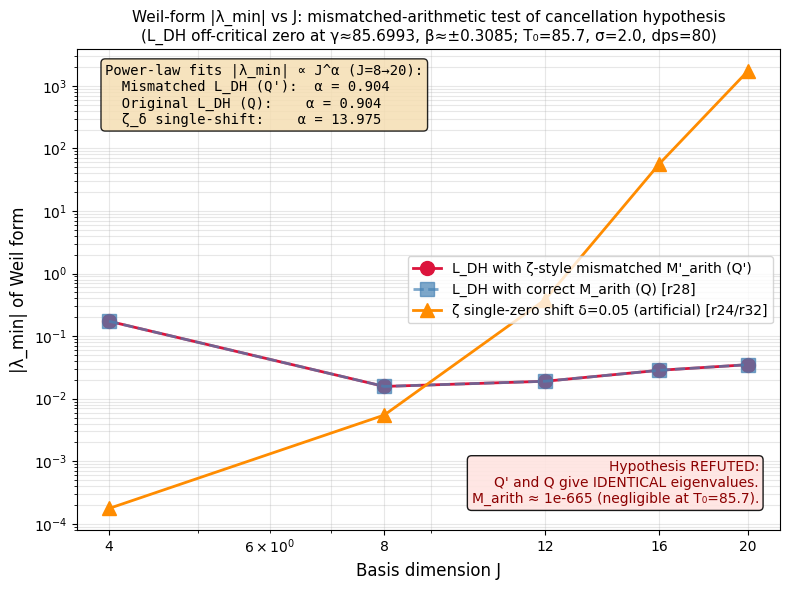

Figure saved.


In [22]:
# Final summary figure
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

J_arr = np.array([4, 8, 12, 16, 20])

# Plot |lambda_min| vs J for all three datasets (mismatched LDH, original LDH, zeta_delta single)
lmin_mismatched_abs = [abs(x) for x in lambda_min_mismatched]
lmin_ldh_abs = [abs(x) for x in ldh_res['lambda_min_ldh_offcrit']]
lmin_zeta_abs = [abs(x) for x in zeta_res['lambda_min_zeta_single_shift']]

ax.loglog(J_arr, lmin_mismatched_abs, 'o-', label="L_DH with ζ-style mismatched M'_arith (Q')", 
 color='crimson', markersize=10, linewidth=2)
ax.loglog(J_arr, lmin_ldh_abs, 's--', label='L_DH with correct M_arith (Q) [r28]', 
 color='steelblue', markersize=10, linewidth=2, alpha=0.7)
ax.loglog(J_arr, lmin_zeta_abs, '^-', label='ζ single-zero shift δ=0.05 (artificial) [r24/r32]', 
 color='darkorange', markersize=10, linewidth=2)

# Annotate fits
ax.text(0.04, 0.97, 
 f"Power-law fits |λ_min| ∝ J^α (J=8→20):\n"
 f" Mismatched L_DH (Q'): α = {slope:.3f}\n"
 f" Original L_DH (Q): α = {slope_ldh:.3f}\n"
 f" ζ_δ single-shift: α = {slope_zeta_s:.3f}",
 transform=ax.transAxes, va='top', ha='left',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85),
 fontsize=10, family='monospace')

ax.text(0.97, 0.05, 
 "Hypothesis REFUTED:\n"
 "Q' and Q give IDENTICAL eigenvalues.\n"
 "M_arith ≈ 1e-665 (negligible at T₀=85.7).",
 transform=ax.transAxes, va='bottom', ha='right', color='darkred',
 bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.9),
 fontsize=10)

ax.set_xlabel('Basis dimension J', fontsize=12)
ax.set_ylabel('|λ_min| of Weil form', fontsize=12)
ax.set_title('Weil-form |λ_min| vs J: mismatched-arithmetic test of cancellation hypothesis\n'
 '(L_DH off-critical zero at γ≈85.6993, β≈±0.3085; T₀=85.7, σ=2.0, dps=80)', fontsize=11)
ax.legend(loc='center right', fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks([4, 8, 12, 16, 20])
ax.set_xticklabels([4, 8, 12, 16, 20])

plt.tight_layout()
plt.savefig('weil_mismatched_arith_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")
